## Data description

The rows in the dataset represent patients and the columns represent information like body measurements, results from various blood tests, and lifestyle choices. You will use the dataset to explore the relationship between cardiac disease, body measurements, blood markers, and lifestyle choices.

File name: medical_examination.csv

| Feature | Variable Type | Variable      | Value Type |
|:-------:|:------------:|:-------------:|:----------:|
| Age | Objective Feature | `age` | int (days) |
| Height | Objective Feature | `height` | int (cm) |
| Weight | Objective Feature | `weight` | float (kg) |
| Gender | Objective Feature | `gender` | categorical code |
| Systolic blood pressure | Examination Feature | `ap_hi` | int |
| Diastolic blood pressure | Examination Feature | `ap_lo` | int |
| Cholesterol | Examination Feature | `cholesterol` | 1: normal, 2: above normal, 3: well above normal |
| Glucose | Examination Feature | `gluc` | 1: normal, 2: above normal, 3: well above normal |
| Smoking | Subjective Feature | `smoke` | binary |
| Alcohol intake | Subjective Feature | `alco` | binary |
| Physical activity | Subjective Feature | `active` | binary |
| Presence or absence of cardiovascular disease | Target Variable | `cardio` | binary |


## Instructions

Create a chart similar to `examples/Figure_1.png`, where we show the counts of good and bad outcomes for the `cholesterol`, `gluc`, `alco`, `active`, and `smoke` variables for patients with `cardio=1` and `cardio=0` in different panels.

---
1. Import the data from `medical_examination.csv` and assign it to the `df` variable.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('medical_examination.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   sex          70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


---
2. Add an `overweight` column to the data. To determine if a person is overweight, first calculate their BMI by dividing their weight in kilograms by the square of their height in meters. If that value is > 25 then the person is overweight. Use the value `0` for NOT overweight and the value `1` for overweight.

In [3]:
df

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [4]:
df['overweight'] = ((df['weight'] / (df['height']/100) ** 2) > 25).astype(int)
df

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,1
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,1


---
3. Normalize data by making `0` always good and `1` always bad. If the value of `cholesterol` or `gluc` is 1, set the value to `0`. If the value is more than `1`, set the value to `1`.

In [5]:
df['cholesterol'].value_counts()

cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

In [6]:
df['cholesterol'] = (df['cholesterol'] > 1).astype(int)
df['cholesterol'].value_counts()

cholesterol
0    52385
1    17615
Name: count, dtype: int64

In [7]:
df['gluc'].value_counts()

gluc
1    59479
3     5331
2     5190
Name: count, dtype: int64

In [8]:
df['gluc'] = (df['gluc'] > 1).astype(int)
df['gluc'].value_counts()

gluc
0    59479
1    10521
Name: count, dtype: int64

---
4. Draw the Categorical Plot in the `draw_cat_plot` function.

---
5. Create a DataFrame for the cat plot using `pd.melt` with values from `cholesterol`, `gluc`, `smoke`, `alco`, `active`, and `overweight` in the `df_cat` variable.

In [9]:
df_cat = pd.melt(df,
                 id_vars=['id', 'cardio'],
                 value_vars=['active', 'alco', 'cholesterol', 'gluc', 'overweight', 'smoke'])
df_cat

,id,cardio,variable,value
0,0,0,active,1
1,1,1,active,1
2,2,1,active,0
3,3,1,active,1
4,4,0,active,0
...,...,...,...,...
419995,99993,0,smoke,1
419996,99995,1,smoke,0
419997,99996,1,smoke,0
419998,99998,1,smoke,0


---
6. Group and reformat the data in `df_cat` to split it by `cardio`. Show the counts of each feature. You will have to rename one of the columns for the `catplot` to work correctly.

In [10]:
df_cat_grouped = df_cat.groupby(['cardio', 'variable', 'value']).size().reset_index(name='total')
df_cat_grouped

,cardio,variable,value,total
0,0,active,0,6378
1,0,active,1,28643
2,0,alco,0,33080
3,0,alco,1,1941
4,0,cholesterol,0,29330
5,0,cholesterol,1,5691
6,0,gluc,0,30894
7,0,gluc,1,4127
8,0,overweight,0,15915
9,0,overweight,1,19106


---
7. Convert the data into `long` format and create a chart that shows the value counts of the categorical features using the following method provided by the seaborn library import: `sns.catplot()`.

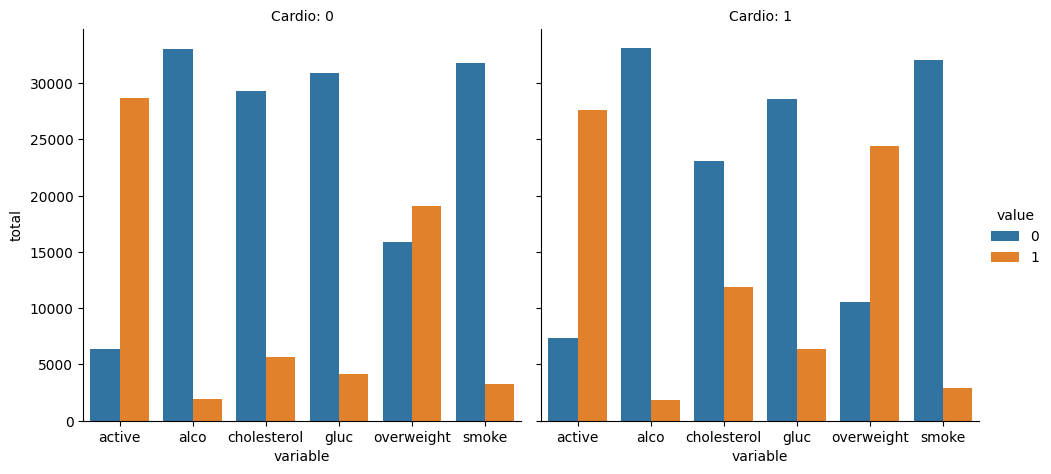

In [11]:
fig = sns.catplot(data=df_cat,
                  kind='count',
                  x='variable',
                  hue='value',
                  col='cardio')

fig.fig.subplots_adjust(top=0.9)
fig.set_axis_labels("variable", "total")
fig.set_titles("Cardio: {col_name}")

---
8. Get the figure for the output and store it in the `fig` variable.

---
9. Do not modify the next two lines.

---
10. Draw the Heat Map in the `draw_heat_map` function.

---
11. Clean the data in the `df_heat` variable by filtering out the following patient segments that represent incorrect data:
    - diastolic pressure is higher than systolic (Keep the correct data with `(df['ap_lo'] <= df['ap_hi'])`)
    - height is less than the 2.5th percentile (Keep the correct data with `(df['height'] >= df['height'].quantile(0.025))`)
    - height is more than the 97.5th percentile
    - weight is less than the 2.5th percentile
    - weight is more than the 97.5th percentile

In [12]:
df_heat = df[ 
    (df['ap_lo'] <= df['ap_hi']) & 
    (df['height'] >= df['height'].quantile(0.025)) & 
    (df['height'] <= df['height'].quantile(0.975)) & 
    (df['weight'] >= df['weight'].quantile(0.025)) & 
    (df['weight'] <= df['weight'].quantile(0.975))
]
df_heat

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,0,0,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,1,0,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,1,0,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,0,0,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,99991,19699,1,172,70.0,130,90,0,0,0,0,1,1,0
69994,99992,21074,1,165,80.0,150,80,0,0,0,0,1,1,1
69995,99993,19240,2,168,76.0,120,80,0,0,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,0,1,0,0,0,1,1


---
12. Calculate the correlation matrix and store it in the `corr` variable.

In [13]:
corr = df_heat.corr()
corr

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
id,1.000000,0.002507,0.003426,0.000326,0.000149,0.003492,0.000484,0.003719,0.002289,-0.002732,-0.000708,0.005891,0.003900,-0.000679
age,0.002507,1.000000,-0.018132,-0.076932,0.070168,0.018689,0.153508,0.129996,0.086990,-0.044371,-0.026970,-0.011445,0.240241,0.089573
sex,0.003426,-0.018132,1.000000,0.505785,0.129979,0.005063,0.059947,-0.037605,-0.021357,0.337436,0.168637,0.007864,0.002320,-0.052930
height,0.000326,-0.076932,0.505785,1.000000,0.251503,0.004586,0.017922,-0.063522,-0.030469,0.187830,0.089785,-0.005661,-0.024102,-0.149570
weight,0.000149,0.070168,0.129979,0.251503,1.000000,0.027030,0.227922,0.135981,0.107072,0.056533,0.059917,-0.014430,0.170042,0.655926
ap_hi,0.003492,0.018689,0.005063,0.004586,0.027030,1.000000,0.072803,0.022807,0.011111,-0.001928,0.000769,-0.000222,0.050556,0.017327
ap_lo,0.000484,0.153508,0.059947,0.017922,0.227922,0.072803,1.000000,0.150362,0.074840,0.023275,0.033042,0.001569,0.327181,0.172212
cholesterol,0.003719,0.129996,-0.037605,-0.063522,0.135981,0.022807,0.150362,1.000000,0.383743,0.012680,0.038446,0.002494,0.203467,0.127986
gluc,0.002289,0.086990,-0.021357,-0.030469,0.107072,0.011111,0.074840,0.383743,1.000000,-0.004157,0.014297,-0.010145,0.088445,0.088109
smoke,-0.002732,-0.044371,0.337436,0.187830,0.056533,-0.001928,0.023275,0.012680,-0.004157,1.000000,0.341200,0.026940,-0.020345,-0.003274


---
13. Generate a mask for the upper triangle and store it in the `mask` variable.

In [14]:
mask = np.triu(np.ones_like(corr, dtype=bool))
mask

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True],
       [False,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True],
       [False, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True],
       [False, False, False,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True],
       [False, False, False, False,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True],
       [False, False, False, False, False,  True,  True,  True,  True,
         True,  True,  True,  True,  True],
       [False, False, False, False, False, False,  True,  True,  True,
         True,  True,  True,  True,  True],
       [False, False, False, False, False, False, False,  True,  True,
         True,  True,  True,  True,  True],
       [False, False, False, False, False, False, False, False,  True,
         

---
14. Set up the `matplotlib` figure.

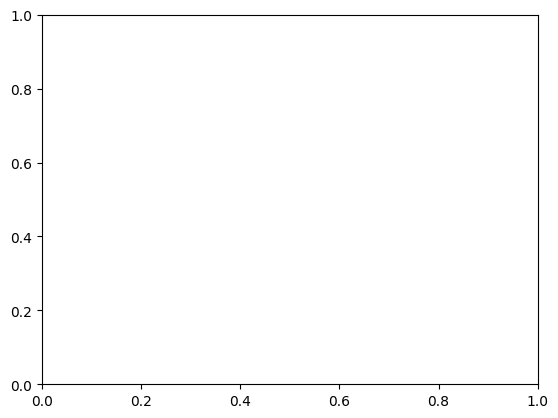

In [15]:
fig, ax = plt.subplots()

---
15. Plot the correlation matrix using the method provided by the `seaborn` library import: `sns.heatmap()`.

<Axes: >

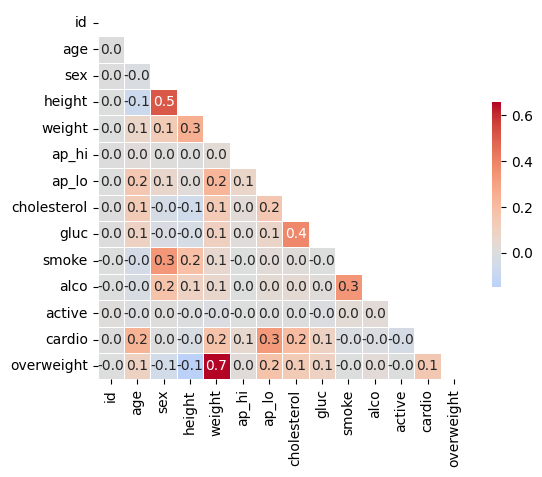

In [16]:
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".1f",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    cmap='coolwarm'  # Or try 'RdBu', 'vlag', etc.
)

---
16. Do not modify the next two lines.